# LV5 - klasifikacija - logisitčka regresija

- i u ovoj vježbi bavimo se nadziranim učenjem
- osim predviđanja neke numeričke varijable kao u prošloj vježbi (CO2 emisija u g/km), moguće je predviđati y i ako je on neka kategorička varijabla
- taj slučaj kada je y diskretna veličina naziva se problem klasifikacije
- ovisno o mogućim vrijednostima y, postoji više vrsta klasifikacije:
    - ako y ima samo dvije moguće vrijednosti (ima/nema bolest, preživio/nije preživio...), tada se naziva binarna klasifikacija
    - ako y ima više od dvije moguće vrijednosti (tip cvijeta, kvaliteta od 1 do 10...), tada se naziva višeklasna klasifikacija

### Logistička regresija

- iako se zove regresija, koristi se za klasifikaciju
- primarno se koristi za binarnu klasifikaciju, u kojem slučaju zapravo računa vjerojatnost da primjerak pripada klasi 0 ili 1
- radi tako što računa granicu odluke - pravac kojim dijeli podatkovne primjere na dvije klase
- može se iskoristiti i za višeklasnu klasifikaciju, na dva različita načina:
    - više binarnih klasifikatora
        - jedan naspram jedan - za k klasa treba nam k*(k-1) / 2 binarnih klasifikatora i svaki je zadužen za dvije klase
        - jedan naspram ostalih - za k klasa treba nam k klasifikatora, i svaki određuje vjerojatnost za jednu klasu naspram svih ostalih
    - multinomijalna logistička regresija (softmax) - izravno daje vjerojatnost pojedine klase

In [1]:
from sklearn.linear_model import LogisticRegression

### Vrednovanje klasifikacijskih modela

- za problem binarne klasifikacije, možemo imati četiri slučaja za rezultat klasifikacije:
    - TP - true positive - primjerak je pozitivan i model ga je tako i klasificirao
    - TN - true negative - primjerak je negativan i model ga je tako i klasificirao
    - FP - false positive - primjerak je negativan, ali model ga je klasificirao kao pozitivnog
    - FN - false negative - primjerak je pozitivan, ali model ga je klasificirao kao negativnog

- iz ova četiri podatka možemo napraviti matricu konfuzije za model

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

- iz gornja četiri podatka možemo izračunati i određene metrike:

1. Točnost (accuracy) - ukupni udio točno klasificiranih primjeraka među svim primjercima
2. Preciznost (precision) - od svih primjeraka koje je model klasificirao kao pozitivne, koliko ih je stvarno pozitivno?
3. Odziv (recall) - od svih stvarno pozitivnih primjeraka, koliko ih je model klasificirao kao pozitivne?
4. F1-score - kombinacija preciznosti i odziva

na primjeru self-driving automobila:
automobil koji ima visoki odziv i visoku preciznost istovremeno bi bio najbolji, jer npr. ne staje na pješačkom prijelazu kada nema pješaka, ali svaki put kada ima pješaka, on stane. automobil koji ima visoki odziv, ali nisku preciznost će svaki put stati na pješačkom kada vidi pješaka (visoki odziv), ali će jako često stajati na pješačkom i ako nema pješaka (niska preciznost). automobil koji ima visoku preciznost i niski odziv neće nijednom stati ako nema pješaka (visoka preciznost - nema lažno pozitivnih), ali će i puno pješaka zgaziti (niski odziv - ima puno lažno negativnih). automobil koji ima niski odziv i nisku preciznost je tesla fsd.

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sve zajedno:

In [10]:
import pandas as pd

data = pd.read_csv('penguins.csv')

# izbacivanje nedostajućih vrijednosti
data.dropna(axis=0, inplace=True)

# kodiranje
data = pd.get_dummies(data, columns=['island', 'sex'])
data['species'].replace({'Adelie' : 0,
                        'Chinstrap' : 1,
                        'Gentoo': 2}, inplace = True)

# određivanje ulaznih i izlazne varijable
X = data[['bill_length_mm', 'flipper_length_mm']]
y = data['species']

# podjela na train i test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# skaliranje numeričkih značajki
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# stvaranje i učenje modela
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X_train, y_train)

# predviđanje vrijednosti na skupu za treniranje
y_test_predicted = model.predict(X_test)

/tmp/ipykernel_141339/1506999.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['species'].replace({'Adelie' : 0,


u ovoj laboratorijskoj vježbi koristila se funkcija plot_decision_regions koja prima X s dvije značajke, y i model, te prikazuje scatter plot podatkovnih primjera. ako se u zadatku na izlaznom ispitu traži da se vizualiziraju podatkovni primjeri i granica odluke, treba koristiti ovu funkciju! X i y moraju biti numpy array, a ne pandas dataframe

/tmp/ipykernel_141339/2219765817.py:27: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


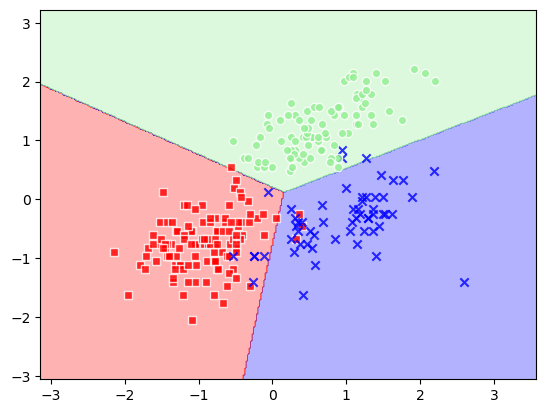

In [16]:
labels= {0:'Adelie', 1:'Chinstrap', 2:'Gentoo'}

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    plt.figure()
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    edgecolor = 'w',
                    label=labels[cl])
        
y_train = y_train.to_numpy()
plot_decision_regions(X_train, y_train, model)